# Generative models

This tutorial will show how to use generative models to solve:
- Generative question answering
- Dialogue generation

However, the same prinicples are applicable to any kind of generative (and discriminative) task.

Yay we made it!

Before starting I need to connect the drive storage to the notebook.

**Optional for Colab users**

Before starting, we can set up the connection with the Google Dive storage, to keep there our documents.
Just execute the following passages:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Make sure that the variable path contains the correct sequence of folders separate by a `'/'` to get to your lecture files

In [ ]:
import os

path = 'Colab Notebooks/NLP-tutorials-2026/Session_8_Generative_models_and_LLMs'

os.chdir(f'/content/drive/MyDrive/{path}')
os.getcwd()

## Causal models




In the previous tutorials we have seen different application of BERT models, i.e. **encoder-only** models. Originally, the transformer architecture was composed by both an **encoder** and **decoder** component, working together to take sequences of tokens as input and generate **one token at a time in output**.

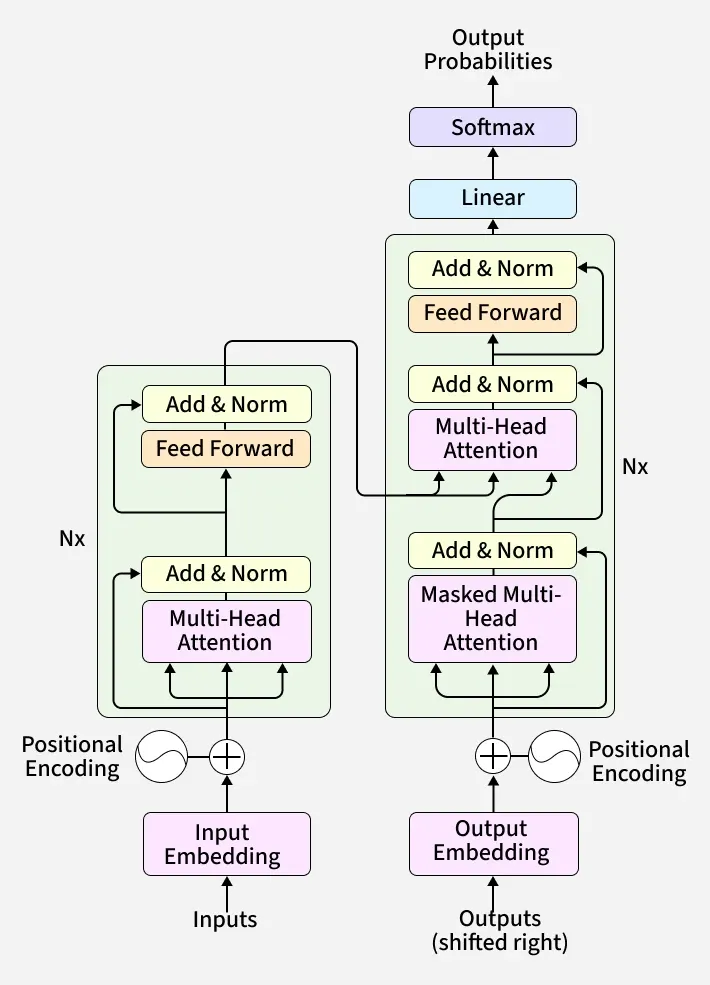

But, how does this work? How do we build a system able to generate text?

## Next Token Prediction (Base Models)

Completion Generation Models: the **base model** is the raw pretrained model that has learned general language patterns from large-scale text—but has not been fine-tuned for any specific task, style, or instruction-following behavior.

The model aims to predict the most likely sequence as a conditional probability of the next token having all previous tokens at the input:

$$
P(w_1, \ldots, w_T) = \prod_{t=1}^{T} P(w_t \mid w_{<t})
$$

This is called **causal decoding** that is implemented via **masked self-attention mechanism** in decoders.
> In decoders generative process models **conditional distribution** of input and output variable. In contrast, discriminative modeling relies on **joint distribution**, as it is done in encoder models.

Let's remind the standard formula of attention:
$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left( \frac{QK^{\mathsf{T}}}{\sqrt{d_k}} \right) V
$$

Mask is an additional lower-triangular matrix that is added to a dot-product before the softmax computation of attention weights:

<div>
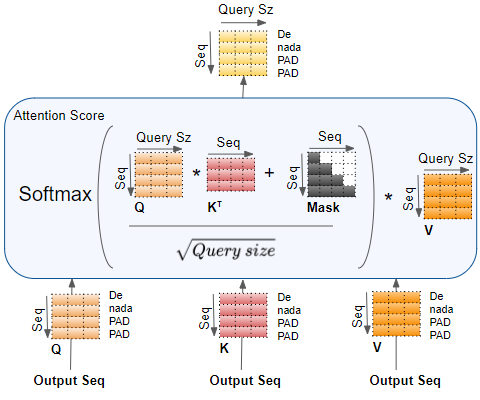
</div>

TDS blog on Transformer Architechture: https://towardsdatascience.com/transformers-explained-visually-part-3-multi-head-attention-deep-dive-1c1ff1024853/

Fair enough, so what?

Let's try out some of the oldest model: GPT-2 https://huggingface.co/docs/transformers/en/model_doc/gpt2.

Let's use `pipeline` object from transformers. Define the pipeline and try generation.

https://huggingface.co/docs/transformers/en/main_classes/pipelines#transformers.pipeline

In [ ]:
import torch
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
import torch
from transformers import pipeline

pipeline = pipeline(task="text-generation", model="openai-community/gpt2", dtype=torch.float16, device=0)

Let's try to put some text as input.

In [ ]:
output = pipeline("Today the weather is really ")
print()
print("Output of the model:")
print()
print(output[0]['generated_text'])

Ok, the text looks good but it is quite nonsensical, let's try to ask something more precise

In [ ]:
output = pipeline("What is the capital of italy?")
print()
print("Output of the model:")
print()
print(output[0]['generated_text'])

Well, even though it has all the reasons, this generations are quite bad, how can we make use of models such that? (or better, why people back in 2020 were so excited about that?)

Turns out that having a model able to generate long coherent and syntactical correct text was already a huge achievements! The missing piece was just a littel bit of **fine-tuning**.

Fine-tuning is nothing but **another step on the training process**, where, in case of **causal generative models** like GPT-2 or the full transformer, translates into **Next-token-prediction** training applied on a **specialised dataset.**

This is exactly what people from Google did initially with the **FLAN-T5** project. They fine-tuned a full transformer model (encoder-decoder) to be used in specialised tasks. https://arxiv.org/pdf/2210.11416

 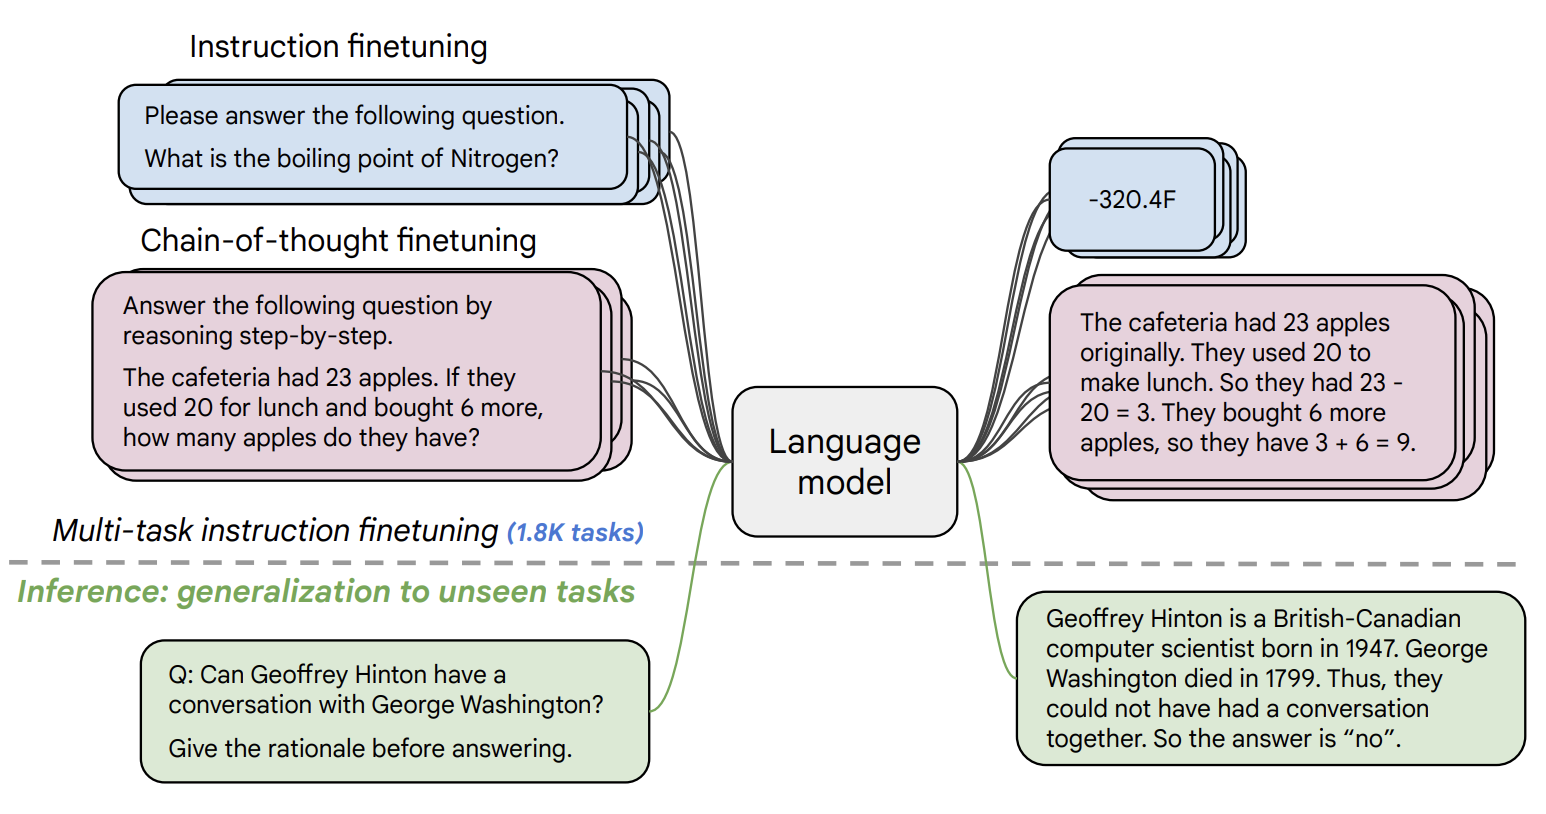

Let's see if this model is better than GPT-2...this time, let's use the standard way to load and generate with `transformers` library. First we load the `tokenizer` and the `model` by searching for their repository in the HugginFace website.
https://huggingface.co/docs/transformers/model_doc/flan-t5

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")



Now, we need to tokenize a string and passes it to the `model.generate() `function.

In [ ]:
input_str = """Please answer the following question.
What is the capital of Italy?"""
inputs = tokenizer(input_str, return_tensors="pt")
outputs = model.generate(**inputs)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True)[0])

Wow it worked! So fine tuning really helped!

The other thing that helped having better and more powerful models was increasing their `size`. Nowadays, Large Language Models vary their size from few billions parameters to trillions! We now explore small open-source models.

# Large Language Models

We are going to use generative model based on Llama from Meta. Llama family is a collection of **Generative** language models based on **decoder-only architecture**.

TDS blog: https://towardsdatascience.com/deep-dive-into-llama-3-by-hand-%EF%B8%8F-6c6b23dc92b2/

HF model: https://huggingface.co/meta-llama/Llama-3.2-1B

To use Llama models, you need Hugging Face authentification. For that create your HF token at

https://huggingface.co/settings/tokens

HF token is free. Once you have it, go to the Llama model page, login and request access. Then setup your HF key either by setting HF_TOKEN environment variable in the code or in collab keys (left pannel, key sign); or with `huggingface_hub.login` function:

In [ ]:
from huggingface_hub import login
login()

### Loading and using an LLM

Llama-3.2 is designed to be small yet powerful, with "only" 1 and 3 billion parameters. It was released in 2025, and has been fine-tuned on an instruction-tuning dataset (of agent-user dialog) to become a chatbot.


We'll need a GPU, so first change the runtime to make use of one, (e.g. a T4 instance)
Then install the HuggingFace Transformers library and some related libraries, such as accelerate.

In [ ]:
!pip install -q -U transformers

Now load a few libraries from Huggingface transformers:

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline


We will shortly start sampling output from an LLM. When we do, in order to make the sampling repeatable, we can set the random seed to a particular value. (Doing this is not necessary to run the rest of the code.)

In [ ]:
torch.random.manual_seed(0)


Let's now download the model and load it onto the GPU.

The particular model we will use is the Llama-3.2-1B-Instruct, which has a maximum context window of 128k tokens and has, as we said before, been instruction tuned to work as a chatbot.

---



In [ ]:
model_name = "meta-llama/Llama-3.2-1B-Instruct"

In [ ]:

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=True,
)

Did you see how big the model is?

Let's have a quick look at the structure of the model that's we've just loaded:

In [ ]:
model

We can see from Embedding module that the vocabulary size is 32064 and the embedding size is 3072 (much smaller than the 12k embeddings used in GPT3 ;-))
We can also see that the model contains 32 Transformer blocks, (which it calls Phi3Decoder layers).

We'll also need the tokenizer, so let's load it:

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

And have a look if there's some information about the tokenizer:

In [ ]:
tokenizer

Note all of the special tokens, such as |system| and |user| that have been used in dialog training data to fine-tune the chatbot.

Now that we have a model and a tokenizer, we can combine them together in a pipeline:

In [ ]:
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

And we can start to create some messages to send to the LLM. We'll do that with a particular structure, consisting of *system* and *user* instructions.

Let's tell the LLM to act like a Python developer and to write for us some code for a particular algorithm:

In [ ]:
messages = [
    {"role": "system", "content": "Your are a Python developer."},
    {"role": "user", "content": "Help me generate a quick-sort algorithm"},
]

The message format above will produce text according to a particular template. The generated text sent to the chatbot should look something like the image below:
 - image source: https://colab.research.google.com/drive/1rt318Ew-5dDw21YZx2zK2vnxbsuDAchH?usp=sharing#scrollTo=AJ0VwUb9tT5K

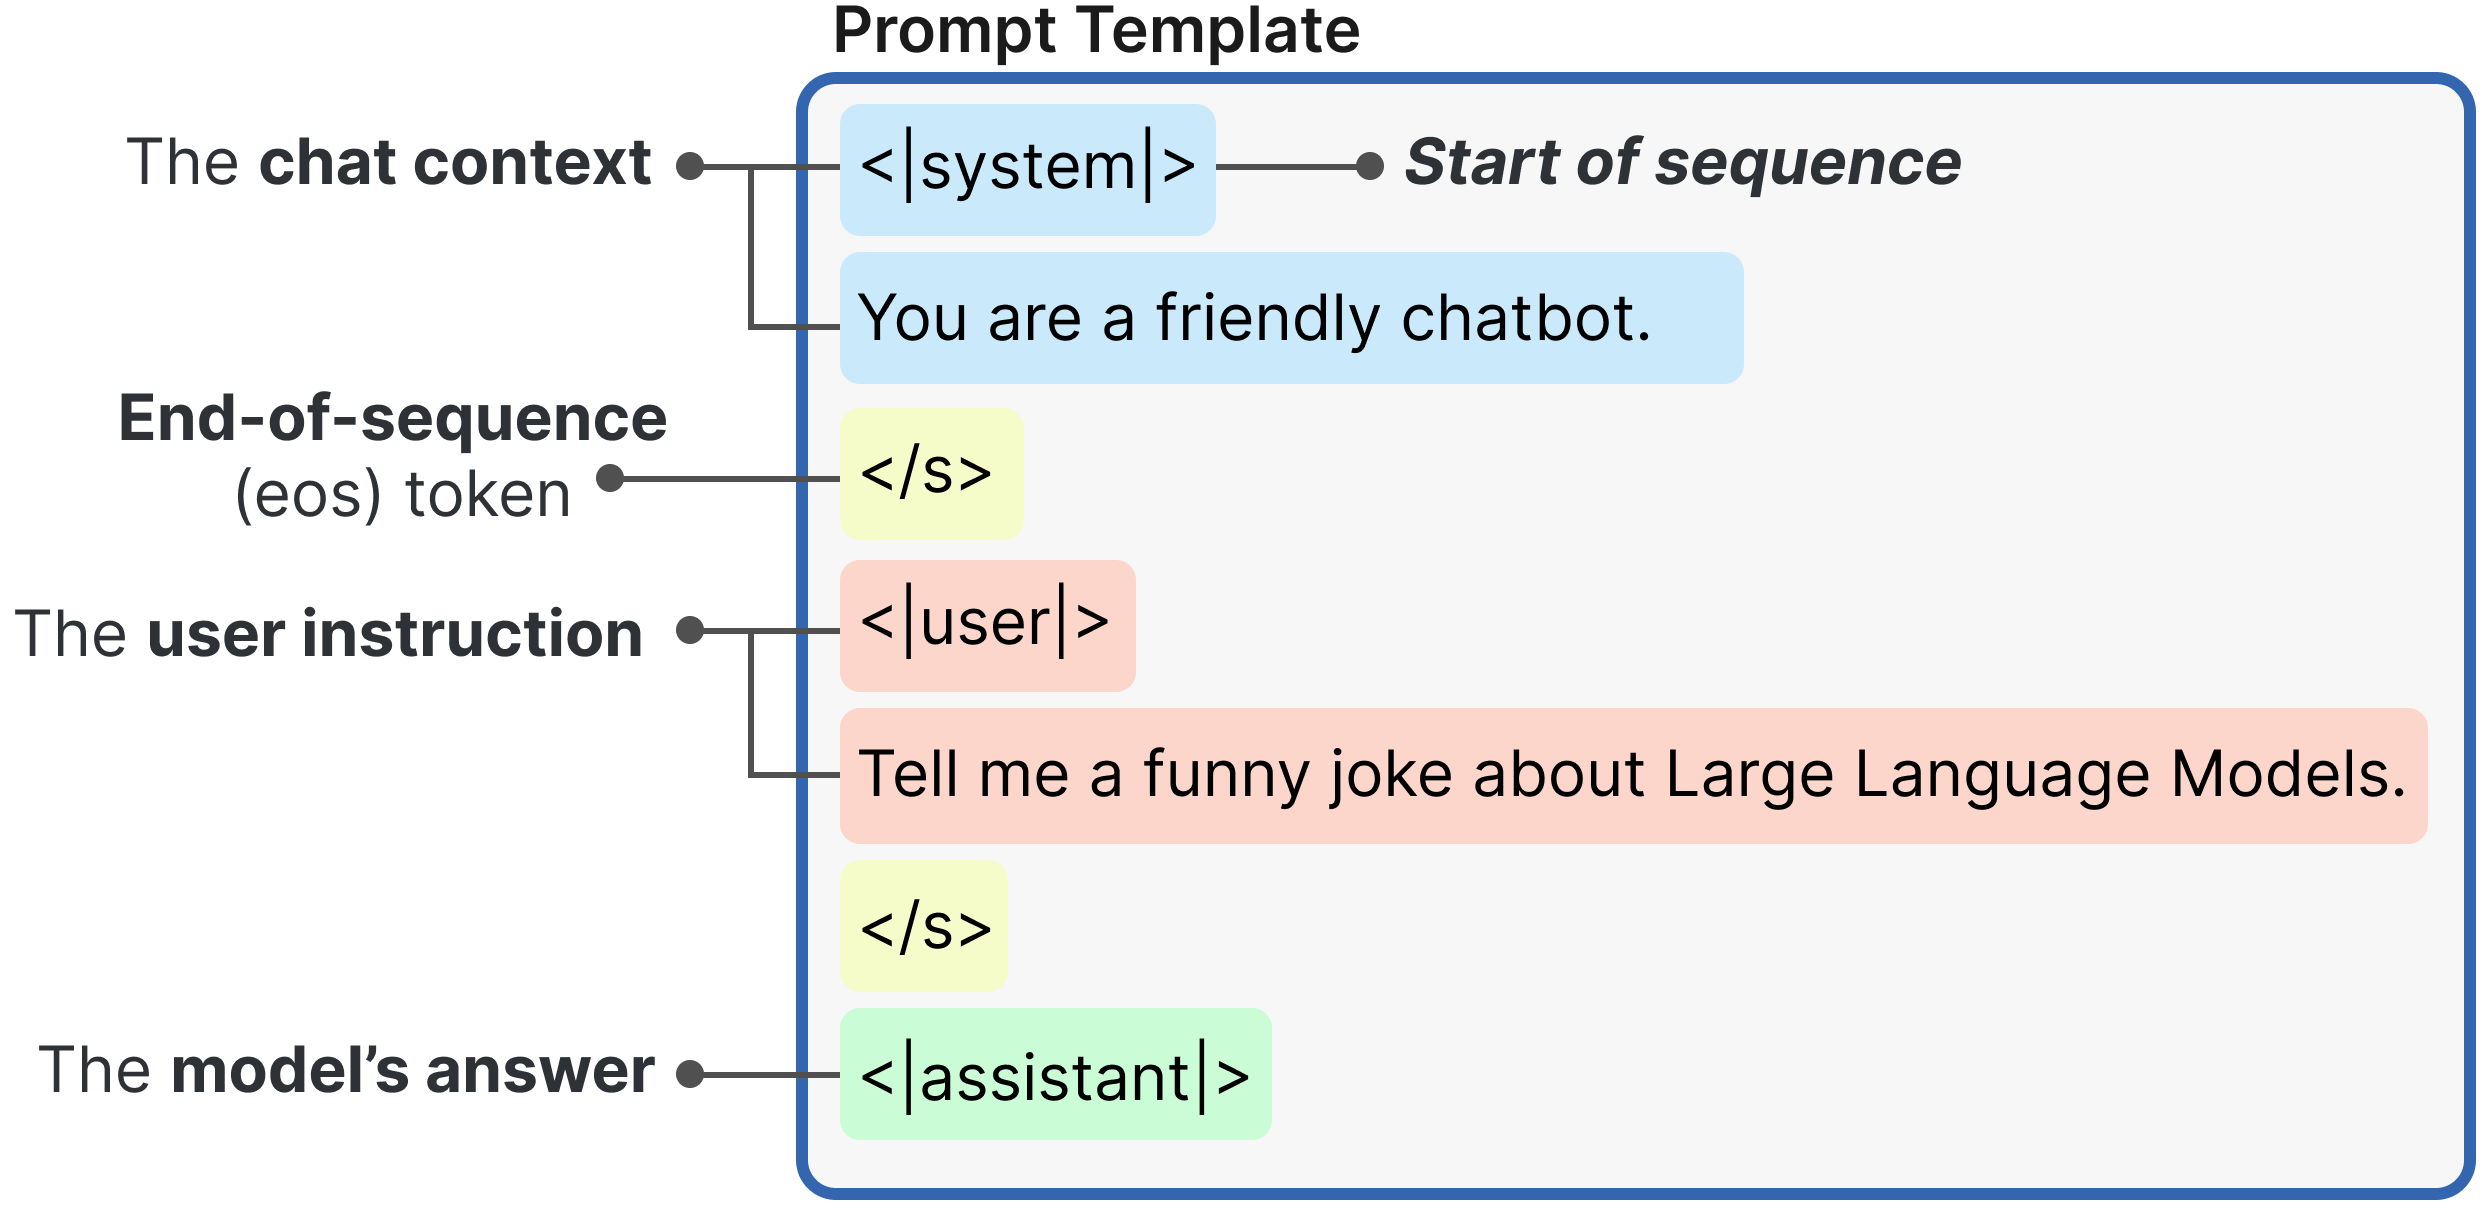

Before giving the message to the chatbot, we need to specify how it should generate text by setting a few parameters, such as whether the LLM should sample and what the temperature for the sampling should be:

In [ ]:
generation_args = {
    "max_new_tokens": 600,
    "return_full_text": False,
    "temperature": 0.3,
    "do_sample": True,
}

Now let's generate the output text:

In [ ]:
output = pipe(messages, **generation_args)
print(output[0]['generated_text'])

Wow, that is impressive!

Try copying the code generated into the cell below to see whether it actually works...

In [ ]:
def quicksort(arr):
    """
    Sorts an array using the quicksort algorithm.

    Args:
        arr (list): The array to be sorted.

    Returns:
        list: The sorted array.
    """
    # Paste here the code from LLM


def main():
    # Test the quick sort function
    arr = [5, 2, 8, 3, 1, 6, 4]
    print("Original array:", arr)
    sorted_arr = quicksort(arr)
    print("Sorted array:", sorted_arr)


if __name__ == "__main__":
    main()

Did it work? How scary is that?

Now let's try some other requests. Maybe tell the model to be a chatbot rather than a programmer...

In [ ]:
system_prompt = "You are a friendly chatbot."

Given the obvious power of this model, we should ask a pertinent question ;-)


In [ ]:
user_request = "Who did you send to kill John Connor?" # Change to nasty chatbot

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_request},
]

pipe(messages, **generation_args)

OK, fair enough. Let's give it a bit of a friendlier instruction then:

In [ ]:
user_request = "Tell me a bedtime story about a boy named Nico who comes from Veneto."

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_request},
]

output = pipe(messages, **generation_args)[0]['generated_text']
print(output)

Amazing. Such a beautiful story ...

Let's see how smart this model is.

First we'll define a function to generate the ouptut in the format we want ...

In [ ]:
def chatbot(user_request):
  system_prompt = "You are a friendly chatbot."
  messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_request},
  ]
  output = pipe(messages, **generation_args)
  return output[0]['generated_text']

And now let's ask some tricky questions:

In [ ]:
chatbot("What is the capital of Brazil?")

looks right

In [ ]:
chatbot("What type of car did Doc drive in 'Back to the Future'?")

Yep, it got the movie!

Can it do addition?

In [ ]:
chatbot('what is 1234567 plus 1111111?')

That did not worked! What about multiplication?

In [ ]:
chatbot('what is 101001 times 12?')

How about we ask a logical question?

In [ ]:
chatbot("Andrew's father has two children. One of them is named Matthew. What is the name of the other child?")

Too easy! Better than the old ChatGPT ;-)

And can it spell?

In [ ]:
chatbot("Write 20 different words that start with aba")

Let's ask some general knowledge and trivia ...

In [ ]:
chatbot("Did Albert Einstein ever live in Italy?")

OK, what about current affairs?

In [ ]:
chatbot("Who won the 2023 Tour de France?")

What if we found some information online that contained the answer?

In [ ]:
import urllib.request
import bs4 as bs
import re

# Define a User-Agent to avoid the 403 Forbidden error
url = 'https://en.wikipedia.org/wiki/2023_Tour_de_France'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})

html_doc = urllib.request.urlopen(req).read()
parsed_doc = bs.BeautifulSoup(html_doc, 'lxml')
page = '\n'.join(p.text for p in parsed_doc.find_all('p'))
print(page[:1000]) # Printing the first 1000 characters to verify


Now let's expand the prompt with the contextual information.

In [ ]:
system_prompt = "You are a friendly chatbot"
question = "Who won the 2023 Tour de France?"
document = page[:1000]

user_request = "Answer the user question: '" + question + "' \n\n based on the information in the document: \n```\n" + document + "\n```\n\n"
messages = [
  {"role": "system", "content": system_prompt},
  {"role": "user", "content": user_request},
]
output = pipe(messages, **generation_args)
print(output[0]['generated_text'])

Nice we did it!

What else could we get the model to do?
- Maybe summarise?

In [ ]:
user_request = "Summarize in 50 words the information in the document: \n```\n" + document + "\n```\n\n"
messages = [
  {"role": "system", "content": system_prompt},
  {"role": "user", "content": user_request},
]
output = pipe(messages, **generation_args)
print(output[0]['generated_text'])

Or translate?

In [ ]:
user_request = "Transalte to Italian the information in the document: \n```\n" + document + "\n```\n\n"
messages = [
  {"role": "system", "content": system_prompt},
  {"role": "user", "content": user_request},
]
output = pipe(messages, **generation_args)
print(output[0]['generated_text'])

### Tokenize and generate - under the hood




Ok, that was fun, enough playing. Now let's see how the `pipeline()` function works under the hood. In other words, let's try to understand how transformers works with the code. Let's go through embedding and forward pass with `AutoModelForCausalLM`.

In [ ]:
base_tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
base_model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-1B",
    device_map="auto",
    dtype=torch.float16
)
print("Special tokens:", base_tokenizer.all_special_tokens)
print("Max context length in tokens:", getattr(base_tokenizer, 'model_max_length', 'unknown'))

Tokenize one sample:

In [ ]:
text = "I am going for a walk. The sky is"
inputs = base_tokenizer(text, return_tensors="pt").to(base_model.device)
input_tokens = base_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
print(input_tokens)

If we run the sequence through the model, we get a series of logits as output.
Since we are using an **autogressive model**, in the last position we will have the logits of next token.

In [ ]:
outputs = base_model(**inputs)
print(outputs.logits)
print(outputs.logits.shape)

We can run these logits through a $\mathrm{softmax}(\cdot)$ and obtain the probability distribution over tokens:
- for each possible token we have the probability of it being the next in the sequence.
- We can sample a token from this probability distribution and pass it to input to get the next new token.
- We can iterate this process to complete a response.

Generation is continues until the special `end_of_sequence` token is generated, or until the specified number of generated tokens is reached.

This is how the `next token` was generated autoregressively at each step:

In [ ]:
# Iterate over each input position and see the most probable next token
for i in range(outputs.logits.shape[1]):
    # probabilities for the next token
    p_dist_next = torch.softmax(outputs.logits[:, i], dim=1)
    # most probable token index
    arg_max_idx = torch.argmax(p_dist_next)
    # most probable token
    next_tok = base_tokenizer.convert_ids_to_tokens(int(arg_max_idx))
    # replace teh word start symbol Ġ of BPE tokenizer for readability
    next_tok = next_tok.replace('Ġ', '_')
    input_seq = ''.join(input_tokens[:i + 1]).replace('Ġ', '_')
    print(input_seq + ' --> ' + next_tok)

The last generated token is actually the next token for the full input sequence:

In [ ]:
p_dist_next = torch.softmax(outputs.logits[:, -1], dim=1)
arg_max_idx = torch.argmax(p_dist_next)
next_token = base_tokenizer.convert_ids_to_tokens(int(arg_max_idx))
print(p_dist_next)
print(p_dist_next.sum())
print(p_dist_next.shape)
print(next_token)

Check `model.generate` and `tokenizer.decode` methods:

In [ ]:
# check what's the output of `decode`
outputs = base_model.generate(**inputs, pad_token_id=base_tokenizer.eos_token_id)
decoded_text = base_tokenizer.decode(outputs[0], skip_special_tokens=True)
print("Decoded text: ", decoded_text)

Output of the `decode` method is a **concatenation of input and generated sequence**. Let's see how to get generated sequence only, and what is its length.

In [ ]:
# check actual generated output
input_token_length = inputs['input_ids'].shape[1]
gen_outputs = outputs[0][input_token_length :]
generated_text = base_tokenizer.decode(gen_outputs, skip_special_tokens=True)
print("Generated text: ", generated_text)
print("Generated length: ", gen_outputs.shape[0])

The length is `20` because the generation config falls back to the default parameter of maximum number of generated tokens, if it is not specified.

Here is how we can check the generation config:

In [ ]:
print(base_model.generation_config)

### Generation parameters

*Auto-regressive language generation* is based on the assumption that the probability distribution of a word sequence can be decomposed into the product of conditional next word distributions:

$$
P(w_{1:T} \mid W_0) = \prod_{t=1}^{T} P(w_t \mid w_{1:t-1}, W_0)
$$


HF blog on generation algorithms: https://huggingface.co/blog/how-to-generate

Check generation parameters in `Parameters for manipulation of the model output logits` section of `GenerationConfig`:
https://huggingface.co/docs/transformers/en/main_classes/text_generation#transformers.GenerationConfig



#### Beam Search
> Beam search is a decoding algorithm that keeps the **top-k most probable partial sequences** at each generation step, expanding them in parallel to find the overall most likely output rather than just the single greedy continuation.

https://en.wikipedia.org/wiki/Beam_search

<div>
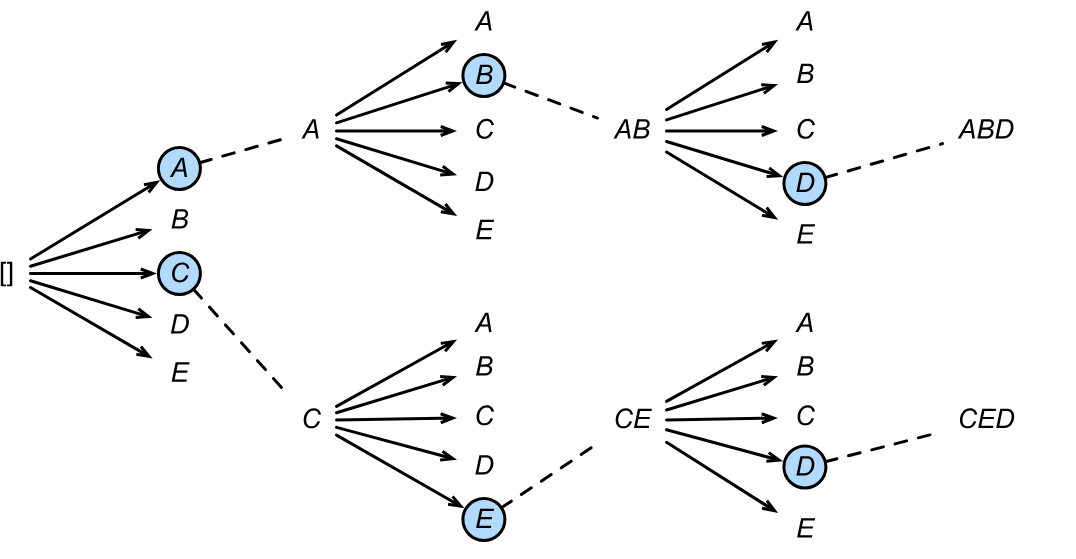
</div>

In [ ]:
outputs = base_model.generate(
    **inputs,
    max_new_tokens=50,
    num_beams=16,
    pad_token_id=base_tokenizer.eos_token_id
)
decoded_text = base_tokenizer.decode(outputs[0], skip_special_tokens=True)
decoded_text

#### Top-k sampling

In Top-K sampling, the K most likely next words are filtered and the probability mass is redistributed among only those K next words.

In [ ]:
from transformers import set_seed
set_seed(42)

In [ ]:
outputs = base_model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=True,
    top_k=100,
    pad_token_id=base_tokenizer.eos_token_id
)
decoded_text = base_tokenizer.decode(outputs[0], skip_special_tokens=True)
decoded_text

#### Top-p (nucleus sampling)

<div>
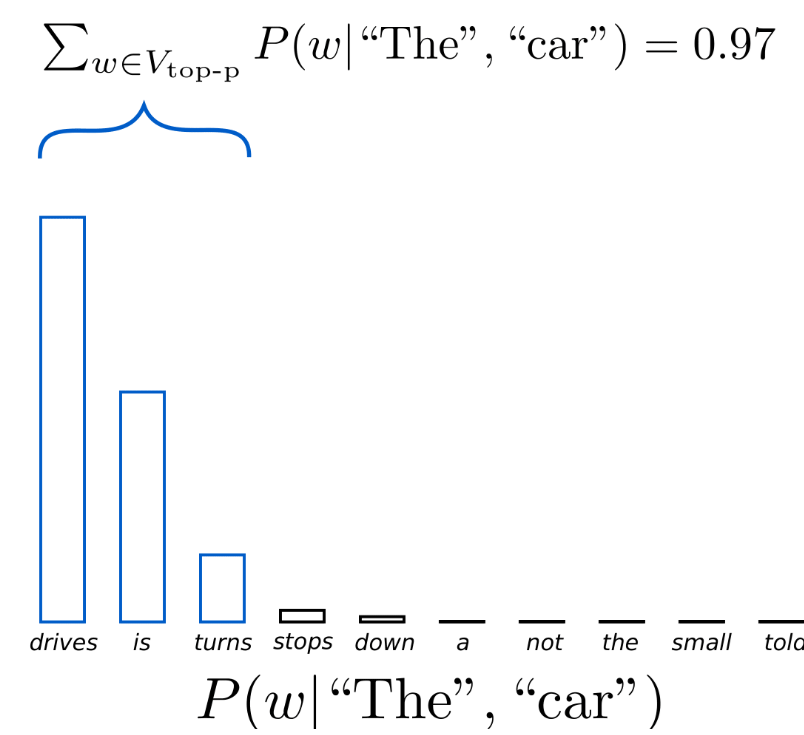
</div>


Consider only first most probable tokens so that their probability sum up to $p \in [0, 1] \subseteq \mathbb{R}$ and zero out others probabilities
Similar to top-$k$ but variable window.

In [ ]:
outputs = base_model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=True,
    top_p=0.97,
    top_k=0,
    pad_token_id=base_tokenizer.eos_token_id
)
decoded_text = base_tokenizer.decode(outputs[0], skip_special_tokens=True)
decoded_text

#### Temperature

**Temperature** is a parameter that controls the randomness of a language model’s output by adjusting the probability distribution of possible next words.

$$
P(w_i) = \frac{e^{(s_i / \tau)}}{\sum_j e^{(s_j / \tau)}}
$$

Temperature $\tau \in \mathbb{R}^+_0$:
- if $\tau > 1$, variability is high, increases the probability of least probable tokens;
- if $\tau = 1$ the distribution is unchanged;
- if $\tau < 1$, better determinism, even more increases the probability of most probable tokens.

<div>
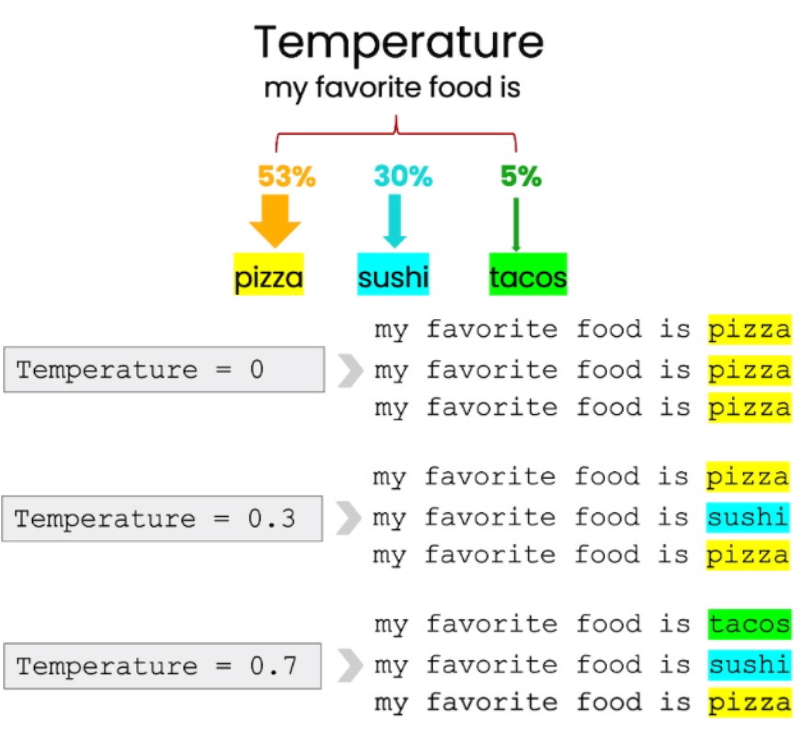
</div>

In [ ]:
outputs = base_model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=True,
    temperature=1.5,
    top_k=0,
    pad_token_id=base_tokenizer.eos_token_id
)
decoded_text = base_tokenizer.decode(outputs[0], skip_special_tokens=True)
decoded_text